# Vendor Matchids With Logevent Overlap

## Objective

Describe matchids containing at least one vendor cookie also observed in `visitorlogevent`. This notebook focuses only on three matchid-level measures:

- `total_cookie_count`: distinct eligible vendor cookies in each matchid
- `overlapping_cookie_count`: distinct vendor cookies also found in logevents
- `activity_coverage_pct`: `100 × overlapping_cookie_count / total_cookie_count`

Vendor-specific total-cookie caps are applied. Overlap-count and activity-coverage thresholds remain unset.

## Scope

- Vendor snapshot: `2026-09-16`
- Logevent window: `2026-09-16` only
- Vendors: Experian, LiveRamp, Throtle
- Deterministic matchid sample: bucket 0 of 10 (10%)
- Cohort: sampled matchids with one or more overlapping cookies
- Experian: `total_cookie_count < 250`
- LiveRamp: `total_cookie_count < 100`
- Throtle: `total_cookie_count < 75`

Counts are exact inside the sampled bucket. Estimated matchid totals multiply sampled counts by 10.

In [1]:
from __future__ import annotations

import importlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LogNorm

SOURCE_DAY = date.fromisoformat('2026-09-28')
MATCHID_SAMPLE_MODULUS = 10
MATCHID_SAMPLE_BUCKET = 0
FORCE_REFRESH = False

OUTPUT_DIR = Path('outputs') / 'vendor_activity_coverage'
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_KEY = (
    f'{SOURCE_DAY}_{SOURCE_DAY}_sample-'
    f'{MATCHID_SAMPLE_BUCKET}-of-{MATCHID_SAMPLE_MODULUS}'
)
STATS_CACHE = OUTPUT_DIR / f'matchid_stats_{CACHE_KEY}.csv.gz'
VENDOR_COLORS = {
    'experian': '#4C78A8',
    'liveramp': '#F58518',
    'throtle': '#54A24B',
}
TOTAL_COOKIE_EXCLUSIVE_LIMITS = {
    'experian': 250,
    'liveramp': 100,
    'throtle': 75,
}
LINE_FILTERS = {
    'experian': {'cookie_intercept': 75, 'coverage_intercept': 60},
    'liveramp': {'cookie_intercept': 80, 'coverage_intercept': 80},
    'throtle': {'cookie_intercept': 25, 'coverage_intercept': 110},
}
HIGH_COVERAGE_EXCEPTION_PCT = 95.0

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format

print(f'Cache: {STATS_CACHE}')
print(f'Matchid sample: {100 / MATCHID_SAMPLE_MODULUS:.2f}%')

Cache: outputs/vendor_activity_coverage/matchid_stats_2026-09-28_2026-09-28_sample-0-of-10.csv.gz
Matchid sample: 10.00%


## Load matchid-level aggregates

Synthetic vendor anchors are excluded: `LR_`, `TH_`, `EP_`, and `EL_`. Real Experian `TA_` identifiers remain eligible.

The warehouse query groups identical count combinations. This keeps the local dataset small without discarding matchids: `matchid_count` records how many sampled matchids occupy each point. The cached aggregate is reused unless `FORCE_REFRESH=True`.

In [2]:
STATS_QUERY = f"""
WITH raw_membership AS (
    SELECT 'liveramp' AS vendor, matchid, uid
    FROM iceberg.crossscreen.liveramp_source
    WHERE day = '{SOURCE_DAY}'
      AND matchid <> 0
      AND substr(uid, 1, 3) <> 'LR_'
      AND mod(matchid, {MATCHID_SAMPLE_MODULUS}) = {MATCHID_SAMPLE_BUCKET}

    UNION ALL

    SELECT 'throtle', matchid, uid
    FROM iceberg.crossscreen.throtle_source
    WHERE day = '{SOURCE_DAY}'
      AND matchid <> 0
      AND substr(uid, 1, 3) <> 'TH_'
      AND mod(matchid, {MATCHID_SAMPLE_MODULUS}) = {MATCHID_SAMPLE_BUCKET}

    UNION ALL

    SELECT 'experian', matchid, uid
    FROM iceberg.crossscreen.experian_source
    WHERE day = '{SOURCE_DAY}'
      AND matchid <> 0
      AND substr(uid, 1, 3) NOT IN ('EP_', 'EL_')
      AND mod(matchid, {MATCHID_SAMPLE_MODULUS}) = {MATCHID_SAMPLE_BUCKET}
),
membership AS (
    SELECT DISTINCT vendor, matchid, uid
    FROM raw_membership
    WHERE uid IS NOT NULL AND uid <> ''
),
event_uids AS (
    SELECT DISTINCT observed_uid AS uid
    FROM iceberg.fact.visitorlogevent vle
    CROSS JOIN UNNEST(
        filter(
            concat(
                ARRAY[coalesce(vle.visitorguid, vle.deviceid)],
                CASE
                    WHEN coalesce(vle.eids, '') <> '' THEN split(vle.eids, '|')
                    ELSE CAST(ARRAY[] AS ARRAY(VARCHAR))
                END
            ),
            value -> value IS NOT NULL
                AND regexp_like(value, '^[A-Za-z0-9_!*-]{{11,512}}$')
                AND NOT regexp_like(value, '^[-01_!*]*$')
        )
    ) AS identifiers(observed_uid)
    WHERE vle.day = '{SOURCE_DAY}'
),
per_matchid AS (
    SELECT
        membership.vendor,
        membership.matchid,
        count(*) AS vendor_cookie_count,
        count_if(event_uids.uid IS NOT NULL) AS observed_cookie_count
    FROM membership
    LEFT JOIN event_uids ON membership.uid = event_uids.uid
    GROUP BY membership.vendor, membership.matchid
)
SELECT
    vendor,
    vendor_cookie_count,
    observed_cookie_count,
    count(*) AS matchid_count
FROM per_matchid
GROUP BY vendor, vendor_cookie_count, observed_cookie_count
ORDER BY vendor, vendor_cookie_count, observed_cookie_count
"""

def run_query(sql: str) -> pd.DataFrame:
    config_dir = Path.home() / '.pulsepoint'
    sys.path.insert(0, str(config_dir))

    from dotenv import load_dotenv

    load_dotenv(config_dir / '.env', override=False)
    dbfuncs = importlib.import_module('dbfuncs')
    return dbfuncs.query2df(sql, print_time=True)

if STATS_CACHE.exists() and not FORCE_REFRESH:
    raw_stats = pd.read_csv(STATS_CACHE)
    print(f'Loaded cache: {STATS_CACHE}')
else:
    raw_stats = run_query(STATS_QUERY)
    raw_stats.to_csv(STATS_CACHE, index=False, compression='gzip')
    print(f'Saved cache: {STATS_CACHE}')

required_columns = {
    'vendor',
    'vendor_cookie_count',
    'observed_cookie_count',
    'matchid_count',
}
missing_columns = required_columns.difference(raw_stats.columns)
if missing_columns:
    raise ValueError(f'Cache misses required columns: {sorted(missing_columns)}')

stats = raw_stats.rename(columns={
    'vendor_cookie_count': 'total_cookie_count',
    'observed_cookie_count': 'overlapping_cookie_count',
}).copy()

numeric_columns = [
    'total_cookie_count',
    'overlapping_cookie_count',
    'matchid_count',
]
stats[numeric_columns] = stats[numeric_columns].apply(pd.to_numeric, errors='raise')

overlap_stats = stats.loc[stats.overlapping_cookie_count.ge(1)].copy()
overlap_stats['activity_coverage_pct'] = (
    100 * overlap_stats.overlapping_cookie_count / overlap_stats.total_cookie_count
)
overlap_stats['total_cookie_exclusive_limit'] = overlap_stats.vendor.map(
    TOTAL_COOKIE_EXCLUSIVE_LIMITS
)
if overlap_stats.total_cookie_exclusive_limit.isna().any():
    missing_vendors = sorted(
        overlap_stats.loc[
            overlap_stats.total_cookie_exclusive_limit.isna(),
            'vendor',
        ].unique()
    )
    raise ValueError(f'Missing total-cookie limits: {missing_vendors}')

sampled_matchids_before_size_filter = int(overlap_stats.matchid_count.sum())
overlap_stats = overlap_stats.loc[
    overlap_stats.total_cookie_count.lt(overlap_stats.total_cookie_exclusive_limit)
].copy()
sampled_matchids_after_size_filter = int(overlap_stats.matchid_count.sum())

assert not overlap_stats.empty
assert overlap_stats.overlapping_cookie_count.le(overlap_stats.total_cookie_count).all()
assert overlap_stats.activity_coverage_pct.between(0, 100).all()

print(f'Aggregate points: {len(overlap_stats):,}')
print(f'Sampled matchids before size filters: {sampled_matchids_before_size_filter:,}')
print(f'Sampled matchids after size filters: {sampled_matchids_after_size_filter:,}')

Query executed in 291.297 seconds
Saved cache: outputs/vendor_activity_coverage/matchid_stats_2026-09-28_2026-09-28_sample-0-of-10.csv.gz
Aggregate points: 6,094
Sampled matchids before size filters: 30,165,123
Sampled matchids after size filters: 30,165,081


## Cohort summary

Weighted percentiles treat `matchid_count` as frequency. They describe sampled matchids, not only the displayed aggregate points.

In [3]:
def weighted_quantile(
    frame: pd.DataFrame,
    value_column: str,
    quantile: float,
    weight_column: str = 'matchid_count',
) -> float:
    ordered = frame.sort_values(value_column)
    cumulative_weight = ordered[weight_column].cumsum()
    cutoff = quantile * ordered[weight_column].sum()
    return float(ordered.loc[cumulative_weight.ge(cutoff), value_column].iloc[0])

summary_rows = []
for vendor, vendor_stats in overlap_stats.groupby('vendor', sort=True):
    sampled_matchids = int(vendor_stats.matchid_count.sum())
    summary_rows.append({
        'vendor': vendor.title(),
        'sampled_matchids': sampled_matchids,
        'estimated_matchids': sampled_matchids * MATCHID_SAMPLE_MODULUS,
        'median_total_cookies': weighted_quantile(vendor_stats, 'total_cookie_count', 0.50),
        'p90_total_cookies': weighted_quantile(vendor_stats, 'total_cookie_count', 0.90),
        'median_overlapping_cookies': weighted_quantile(vendor_stats, 'overlapping_cookie_count', 0.50),
        'p90_overlapping_cookies': weighted_quantile(vendor_stats, 'overlapping_cookie_count', 0.90),
        'median_activity_coverage_pct': weighted_quantile(vendor_stats, 'activity_coverage_pct', 0.50),
        'p90_activity_coverage_pct': weighted_quantile(vendor_stats, 'activity_coverage_pct', 0.90),
    })

summary = pd.DataFrame(summary_rows)
display(summary)

,vendor,sampled_matchids,estimated_matchids,median_total_cookies,p90_total_cookies,median_overlapping_cookies,p90_overlapping_cookies,median_activity_coverage_pct,p90_activity_coverage_pct
0,Experian,8079580,80795800,12.00,35.00,1.00,3.00,12.50,33.33
1,Liveramp,15443358,154433580,17.00,38.00,1.00,4.00,11.11,40.00
2,Throtle,6642143,66421430,3.00,8.00,1.00,2.00,33.33,100.00


## Marginal distributions

Each point shows an observed metric value and its estimated matchid frequency. Cookie-count and coverage axes are linear. Estimated matchid frequency uses a logarithmic axis.

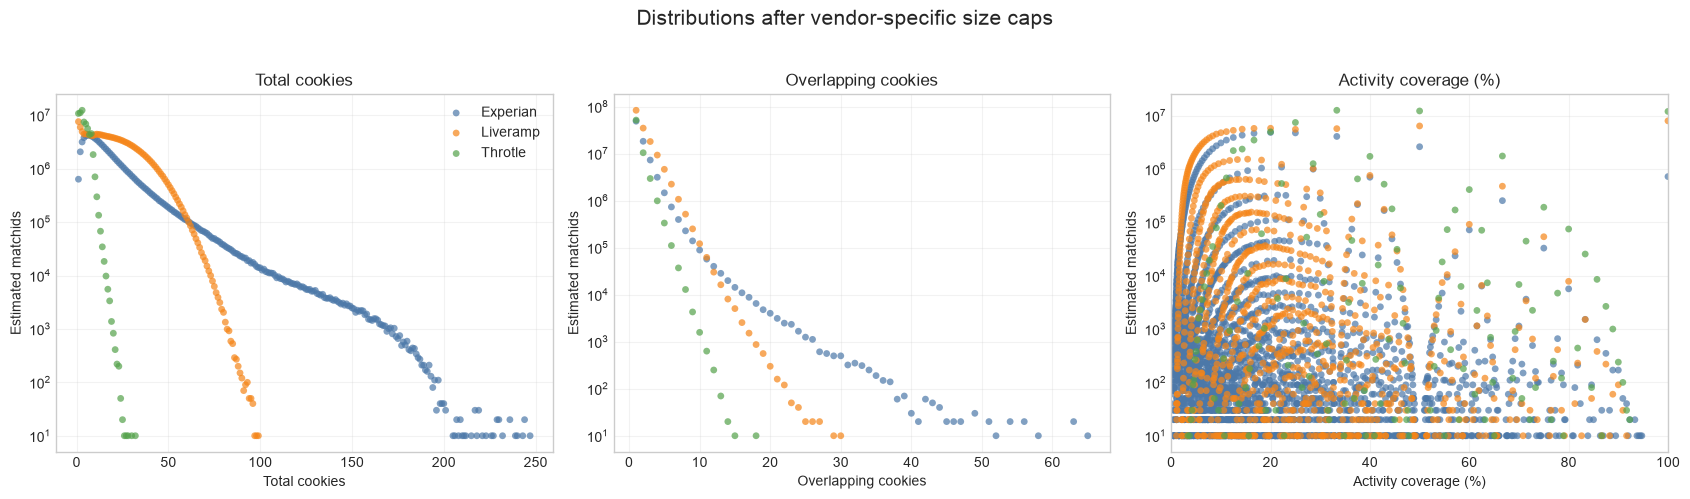

Saved: outputs/vendor_activity_coverage/figures/overlap_distributions_2026-09-28_2026-09-28_sample-0-of-10.png


In [4]:
distribution_specs = [
    ('total_cookie_count', 'Total cookies'),
    ('overlapping_cookie_count', 'Overlapping cookies'),
    ('activity_coverage_pct', 'Activity coverage (%)'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for axis, (column, label) in zip(axes, distribution_specs):
    for vendor, vendor_stats in overlap_stats.groupby('vendor', sort=True):
        distribution = (
            vendor_stats.groupby(column, as_index=False)['matchid_count']
            .sum()
            .sort_values(column)
        )
        axis.scatter(
            distribution[column],
            distribution.matchid_count * MATCHID_SAMPLE_MODULUS,
            s=24,
            alpha=0.70,
            color=VENDOR_COLORS[vendor],
            edgecolors='none',
            label=vendor.title(),
        )
    if column == 'activity_coverage_pct':
        axis.set_xlim(0, 100)
    axis.set_yscale('log')
    axis.set_xlabel(label)
    axis.set_ylabel('Estimated matchids')
    axis.set_title(label)
    axis.grid(True, which='major', alpha=0.25)

axes[0].legend(frameon=False)
fig.suptitle('Distributions after vendor-specific size caps', fontsize=15, y=1.03)
fig.tight_layout()
distribution_path = FIGURE_DIR / f'overlap_distributions_{CACHE_KEY}.png'
fig.savefig(distribution_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {distribution_path}')

## Pairwise scatter distributions

Each point represents one unique combination of total and overlapping cookie counts. Point size and color encode estimated matchid frequency using logarithmic scaling.

The first plot shows the full post-cap population without line filtering. The second plot adds each vendor line. Points passing the line or qualifying for the high-coverage exception remain colored; all other points appear gray.

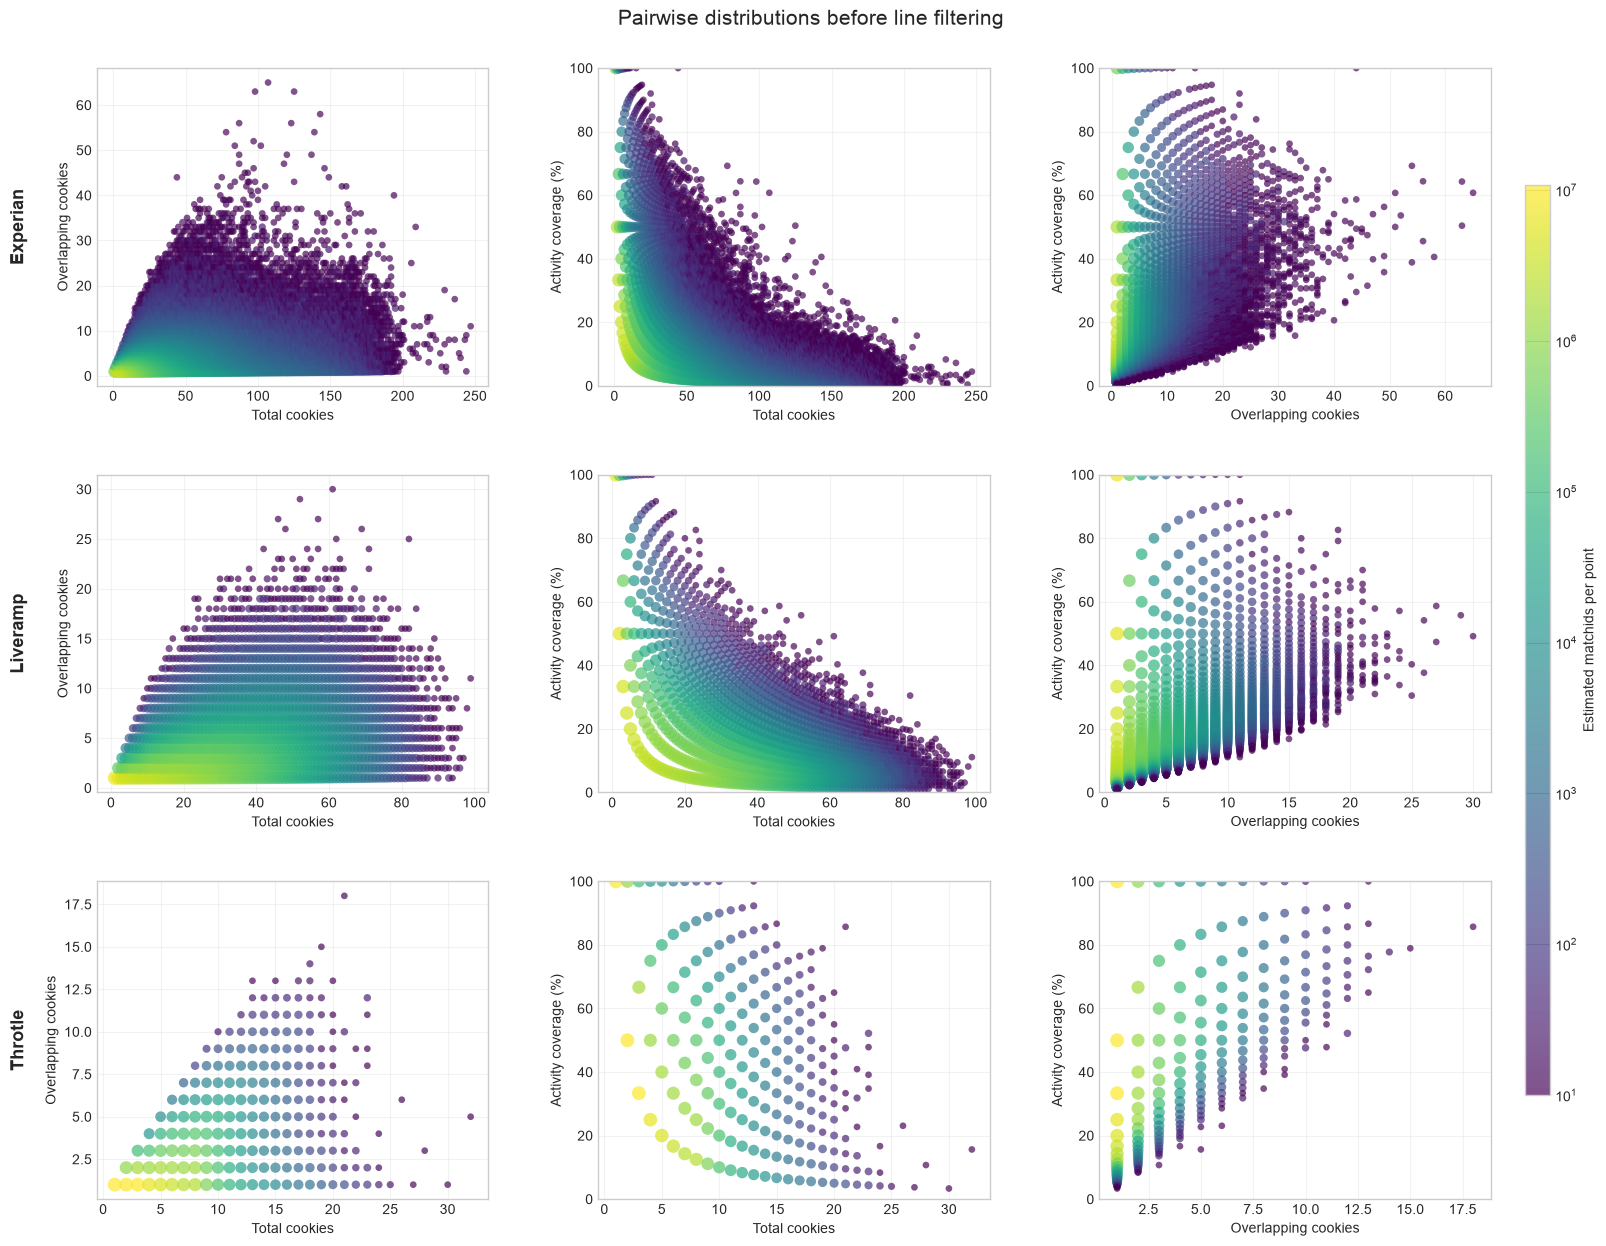

Saved: outputs/vendor_activity_coverage/figures/overlap_pairwise_full_2026-09-28_2026-09-28_sample-0-of-10.png


In [5]:
vendors = sorted(overlap_stats.vendor.unique())
estimated_frequency = overlap_stats.matchid_count * MATCHID_SAMPLE_MODULUS
maximum_estimated_frequency = int(estimated_frequency.max())
minimum_estimated_frequency = int(estimated_frequency.min())
frequency_norm = LogNorm(
    vmin=max(1, minimum_estimated_frequency),
    vmax=maximum_estimated_frequency,
)

def marker_sizes(estimated_frequencies: pd.Series) -> np.ndarray:
    scaled = np.log1p(estimated_frequencies) / np.log1p(maximum_estimated_frequency)
    return 10 + 90 * scaled.to_numpy()

overlap_stats['line_coverage_threshold_pct'] = np.nan
for vendor, parameters in LINE_FILTERS.items():
    vendor_mask = overlap_stats.vendor.eq(vendor)
    coverage_intercept = parameters['coverage_intercept']
    cookie_intercept = parameters['cookie_intercept']
    overlap_stats.loc[vendor_mask, 'line_coverage_threshold_pct'] = (
        coverage_intercept
        * (1 - overlap_stats.loc[vendor_mask, 'total_cookie_count'] / cookie_intercept)
    )

overlap_stats['line_cookie_intercept'] = overlap_stats.vendor.map(
    {vendor: parameters['cookie_intercept'] for vendor, parameters in LINE_FILTERS.items()}
)
overlap_stats['line_filter_exception'] = (
    overlap_stats.activity_coverage_pct.gt(HIGH_COVERAGE_EXCEPTION_PCT)
    & overlap_stats.total_cookie_count.lt(overlap_stats.line_cookie_intercept)
)
overlap_stats['passes_line_filter'] = (
    overlap_stats.activity_coverage_pct.le(overlap_stats.line_coverage_threshold_pct)
    | overlap_stats.line_filter_exception
)

impact_rows = []
for vendor, vendor_stats in overlap_stats.groupby('vendor', sort=True):
    retained = vendor_stats.loc[vendor_stats.passes_line_filter]
    recovered_by_exception = vendor_stats.loc[
        vendor_stats.line_filter_exception
        & vendor_stats.activity_coverage_pct.gt(
            vendor_stats.line_coverage_threshold_pct
        )
    ]
    total_matchids = vendor_stats.matchid_count.sum()
    retained_matchids = retained.matchid_count.sum()
    total_overlap_evidence = (
        vendor_stats.matchid_count * vendor_stats.overlapping_cookie_count
    ).sum()
    retained_overlap_evidence = (
        retained.matchid_count * retained.overlapping_cookie_count
    ).sum()
    impact_rows.append({
        'vendor': vendor.title(),
        'cookie_intercept': LINE_FILTERS[vendor]['cookie_intercept'],
        'coverage_intercept': LINE_FILTERS[vendor]['coverage_intercept'],
        'estimated_matchids_before': total_matchids * MATCHID_SAMPLE_MODULUS,
        'estimated_matchids_retained': retained_matchids * MATCHID_SAMPLE_MODULUS,
        'estimated_matchids_filtered': (total_matchids - retained_matchids) * MATCHID_SAMPLE_MODULUS,
        'estimated_matchids_recovered_by_exception': (
            recovered_by_exception.matchid_count.sum() * MATCHID_SAMPLE_MODULUS
        ),
        'retained_matchid_share_pct': 100 * retained_matchids / total_matchids,
        'retained_overlap_evidence_pct': (
            100 * retained_overlap_evidence / total_overlap_evidence
        ),
    })

line_filter_impact = pd.DataFrame(impact_rows)

pair_specs = [
    ('total_cookie_count', 'overlapping_cookie_count', 'Total cookies', 'Overlapping cookies'),
    ('total_cookie_count', 'activity_coverage_pct', 'Total cookies', 'Activity coverage (%)'),
    ('overlapping_cookie_count', 'activity_coverage_pct', 'Overlapping cookies', 'Activity coverage (%)'),
]

fig, axes = plt.subplots(len(vendors), 3, figsize=(17, 13), squeeze=False)
last_scatter = None
for row_index, vendor in enumerate(vendors):
    vendor_stats = overlap_stats.loc[overlap_stats.vendor.eq(vendor)]
    plot_frequency = vendor_stats.matchid_count * MATCHID_SAMPLE_MODULUS

    for column_index, (x_column, y_column, x_label, y_label) in enumerate(pair_specs):
        axis = axes[row_index, column_index]
        last_scatter = axis.scatter(
            vendor_stats[x_column],
            vendor_stats[y_column],
            s=marker_sizes(plot_frequency),
            c=plot_frequency,
            cmap='viridis',
            norm=frequency_norm,
            alpha=0.68,
            linewidths=0,
        )
        if y_column == 'activity_coverage_pct':
            axis.set_ylim(0, 100)
        axis.set_xlabel(x_label)
        axis.set_ylabel(y_label)
        axis.grid(True, which='major', alpha=0.25)
        if column_index == 0:
            axis.text(
                -0.20,
                0.5,
                vendor.title(),
                transform=axis.transAxes,
                rotation=90,
                va='center',
                ha='center',
                fontsize=13,
                fontweight='bold',
            )

fig.suptitle('Pairwise distributions before line filtering', fontsize=15, y=0.985)
fig.subplots_adjust(left=0.08, right=0.90, bottom=0.07, top=0.94, hspace=0.28, wspace=0.28)
colorbar_axis = fig.add_axes([0.92, 0.15, 0.015, 0.70])
colorbar = fig.colorbar(last_scatter, cax=colorbar_axis)
colorbar.set_label('Estimated matchids per point')
pairwise_full_path = FIGURE_DIR / f'overlap_pairwise_full_{CACHE_KEY}.png'
fig.savefig(pairwise_full_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {pairwise_full_path}')

,vendor,cookie_intercept,coverage_intercept,estimated_matchids_before,estimated_matchids_retained,estimated_matchids_filtered,estimated_matchids_recovered_by_exception,retained_matchid_share_pct,retained_overlap_evidence_pct
0,Experian,75,60,80795800,78827340,1968460,720190,97.56,93.41
1,Liveramp,80,80,154433580,154356420,77160,7975230,99.95,99.78
2,Throtle,25,110,66421430,66341020,80410,153910,99.88,99.35


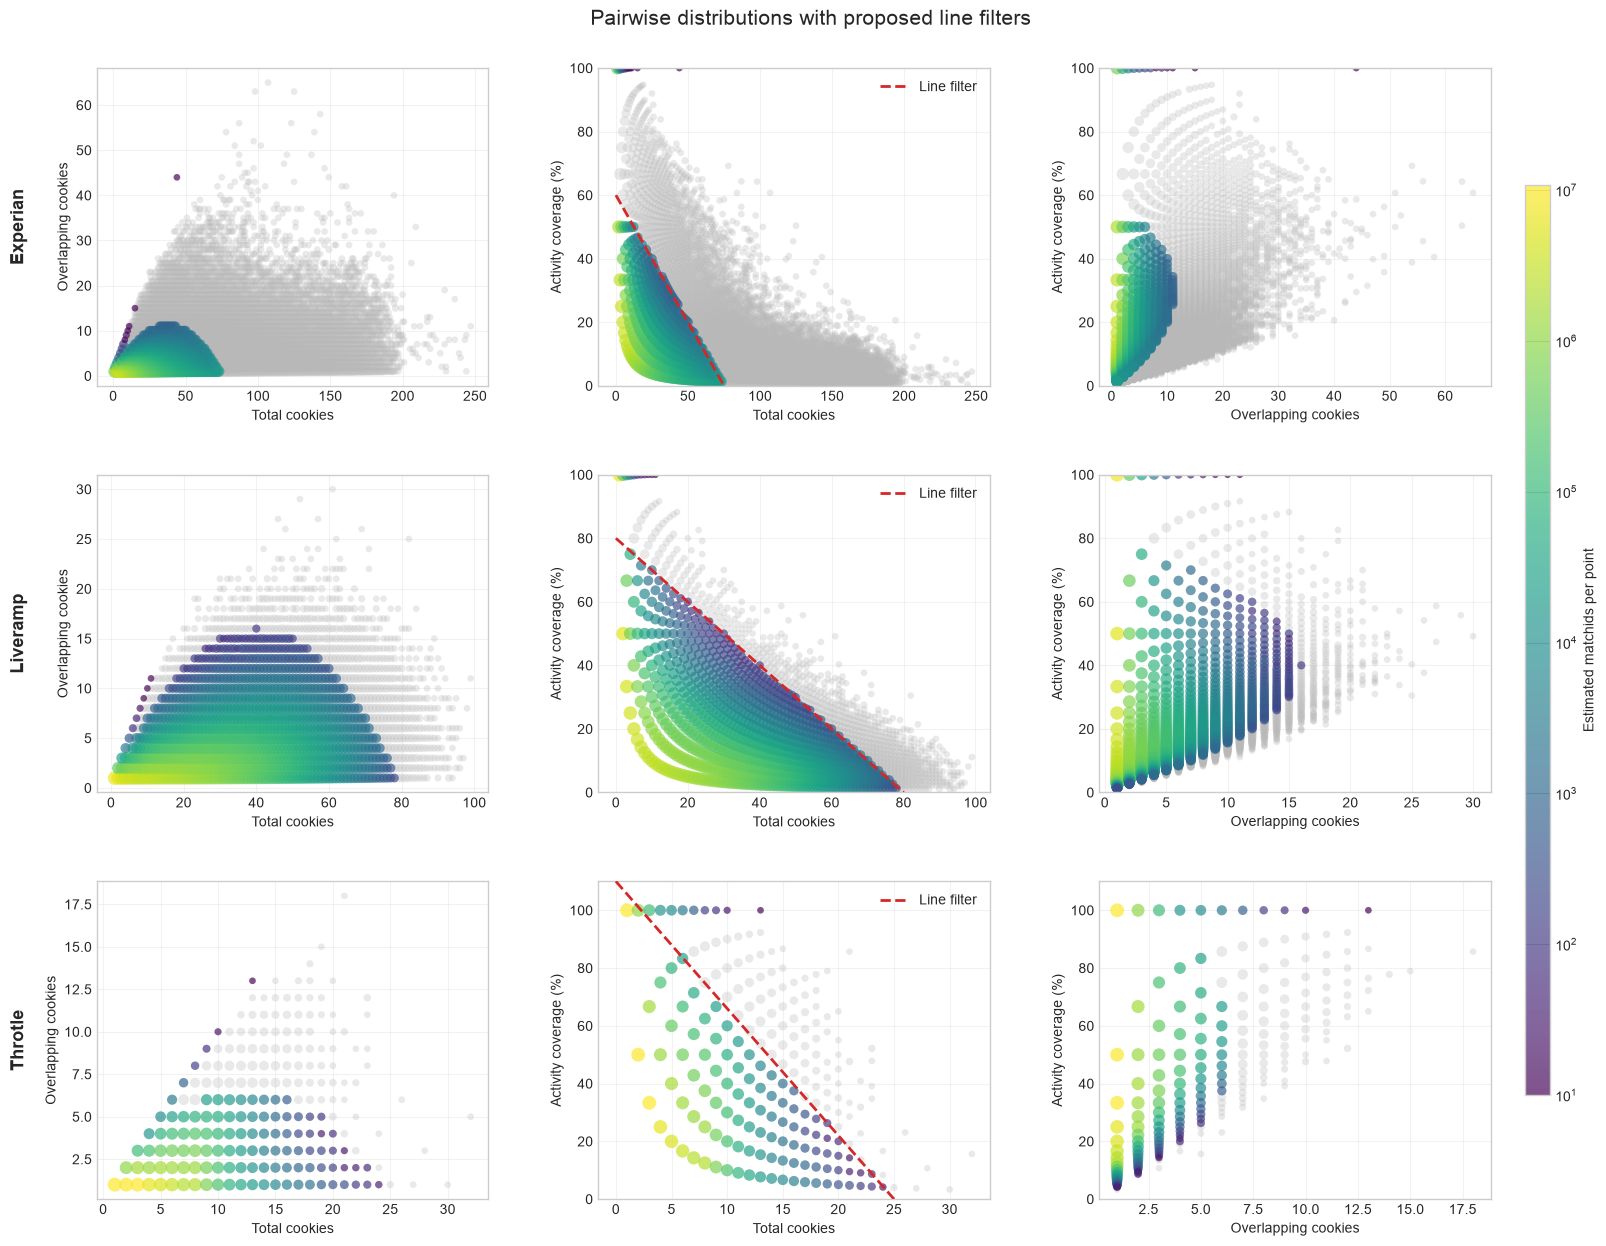

In [7]:
display(line_filter_impact)

fig, axes = plt.subplots(len(vendors), 3, figsize=(17, 13), squeeze=False)
last_scatter = None
for row_index, vendor in enumerate(vendors):
    vendor_stats = overlap_stats.loc[overlap_stats.vendor.eq(vendor)]
    retained_stats = vendor_stats.loc[vendor_stats.passes_line_filter]
    filtered_stats = vendor_stats.loc[~vendor_stats.passes_line_filter]
    retained_frequency = retained_stats.matchid_count * MATCHID_SAMPLE_MODULUS
    filtered_frequency = filtered_stats.matchid_count * MATCHID_SAMPLE_MODULUS

    for column_index, (x_column, y_column, x_label, y_label) in enumerate(pair_specs):
        axis = axes[row_index, column_index]
        axis.scatter(
            filtered_stats[x_column],
            filtered_stats[y_column],
            s=marker_sizes(filtered_frequency),
            color='#B8B8B8',
            alpha=0.30,
            linewidths=0,
            zorder=1,
        )
        last_scatter = axis.scatter(
            retained_stats[x_column],
            retained_stats[y_column],
            s=marker_sizes(retained_frequency),
            c=retained_frequency,
            cmap='viridis',
            norm=frequency_norm,
            alpha=0.68,
            linewidths=0,
            zorder=2,
        )
        if y_column == 'activity_coverage_pct':
            axis.set_ylim(0, max(100, LINE_FILTERS[vendor]['coverage_intercept']))
        if x_column == 'total_cookie_count' and y_column == 'activity_coverage_pct':
            parameters = LINE_FILTERS[vendor]
            cookie_intercept = parameters['cookie_intercept']
            coverage_intercept = parameters['coverage_intercept']
            line_x = np.array([0, cookie_intercept])
            line_y = np.array([coverage_intercept, 0])
            axis.plot(
                line_x,
                line_y,
                color='#D62728',
                linewidth=2,
                linestyle='--',
                label='Line filter',
                zorder=3,
            )
            axis.legend(loc='upper right', frameon=False)
        axis.set_xlabel(x_label)
        axis.set_ylabel(y_label)
        axis.grid(True, which='major', alpha=0.25)
        if column_index == 0:
            axis.text(
                -0.20,
                0.5,
                vendor.title(),
                transform=axis.transAxes,
                rotation=90,
                va='center',
                ha='center',
                fontsize=13,
                fontweight='bold',
            )

fig.suptitle('Pairwise distributions with proposed line filters', fontsize=15, y=0.985)
fig.subplots_adjust(left=0.08, right=0.90, bottom=0.07, top=0.94, hspace=0.28, wspace=0.28)
colorbar_axis = fig.add_axes([0.92, 0.15, 0.015, 0.70])
colorbar = fig.colorbar(last_scatter, cax=colorbar_axis)
colorbar.set_label('Estimated matchids per point')
pairwise_path = FIGURE_DIR / f'overlap_pairwise_scatter_{CACHE_KEY}.png'
fig.savefig(pairwise_path, dpi=160, bbox_inches='tight')
plt.show()


## Population impact and sampling strategy

This section measures the population represented after the overlap requirement, vendor-specific total-cookie caps, line filters, and high-coverage exception. Here, **source matchids** means vendor-specific matchids containing at least one eligible non-empty UID after synthetic vendor-anchor exclusions. Counts are estimated from the deterministic 10% matchid sample by multiplying sampled counts by ten.

In [8]:
population_rows = []
for vendor, source_stats in stats.groupby('vendor', sort=True):
    overlap_vendor_stats = source_stats.loc[
        source_stats.overlapping_cookie_count.ge(1)
    ]
    capped_vendor_stats = overlap_stats.loc[overlap_stats.vendor.eq(vendor)]
    retained_vendor_stats = capped_vendor_stats.loc[
        capped_vendor_stats.passes_line_filter
    ]
    population_rows.append({
        'vendor': vendor.title(),
        'sampled_source_matchids': int(source_stats.matchid_count.sum()),
        'sampled_overlap_matchids': int(overlap_vendor_stats.matchid_count.sum()),
        'sampled_after_size_caps': int(capped_vendor_stats.matchid_count.sum()),
        'sampled_after_line_filter': int(retained_vendor_stats.matchid_count.sum()),
    })

sample_population_funnel = pd.DataFrame(population_rows)
sample_count_columns = [
    'sampled_source_matchids',
    'sampled_overlap_matchids',
    'sampled_after_size_caps',
    'sampled_after_line_filter',
]
total_row = {'vendor': 'Total'}
total_row.update(sample_population_funnel[sample_count_columns].sum().astype(int).to_dict())
sample_population_funnel = pd.concat(
    [sample_population_funnel, pd.DataFrame([total_row])],
    ignore_index=True,
)

population_impact = sample_population_funnel.assign(
    estimated_source_matchids=lambda frame: (
        frame.sampled_source_matchids * MATCHID_SAMPLE_MODULUS
    ),
    estimated_overlap_matchids=lambda frame: (
        frame.sampled_overlap_matchids * MATCHID_SAMPLE_MODULUS
    ),
    estimated_after_size_caps=lambda frame: (
        frame.sampled_after_size_caps * MATCHID_SAMPLE_MODULUS
    ),
    estimated_after_line_filter=lambda frame: (
        frame.sampled_after_line_filter * MATCHID_SAMPLE_MODULUS
    ),
    retained_source_pct=lambda frame: (
        100 * frame.sampled_after_line_filter / frame.sampled_source_matchids
    ),
    retained_overlap_pct=lambda frame: (
        100 * frame.sampled_after_line_filter / frame.sampled_overlap_matchids
    ),
)[
    [
        'vendor',
        'estimated_source_matchids',
        'estimated_overlap_matchids',
        'estimated_after_size_caps',
        'estimated_after_line_filter',
        'retained_source_pct',
        'retained_overlap_pct',
    ]
]
display(population_impact)

,vendor,estimated_source_matchids,estimated_overlap_matchids,estimated_after_size_caps,estimated_after_line_filter,retained_source_pct,retained_overlap_pct
0,Experian,222674660,80796190,80795800,78827340,35.40,97.56
1,Liveramp,541158900,154433610,154433580,154356420,28.52,99.95
2,Throtle,296369580,66421430,66421430,66341020,22.38,99.88
3,Total,1060203140,301651230,301650810,299524780,28.25,99.30


### What the retained population represents

For the 2026-09-16 snapshot, the sample estimates 1,051,147,080 source vendor-matchids. Requiring at least one logevent-overlapping cookie reduces that population to 308,745,130. The existing total-cookie caps remove an estimated 490 additional vendor-matchids. The line filters, after applying the exception, remove another 2,802,770 and leave an estimated 305,941,870 retained vendor-matchids.

The retained population therefore represents **29.11% of source vendor-matchids** and **99.09% of matchids already having logevent overlap**. Compared with the line alone, the exception recovers an estimated 9,041,450 matchids. Most population reduction comes from the overlap requirement, not the line filters. Totals sum vendor populations; they do not deduplicate matchids appearing across vendors.

The exception retains every matchid with activity coverage above `HIGH_COVERAGE_EXCEPTION_PCT` (95% by default) when its total-cookie count remains below its vendor's cookie intercept. Those matchids stay colored even when they lie above the red line.

### Can this computation run locally?

The notebook can run locally because the warehouse query compresses the 10% sample into 7,227 aggregate count combinations. Local filtering and plotting operate on those aggregate rows, not on 105,114,708 sampled matchid records.

A matchid-level local computation should not materialize the estimated 305.9 million retained vendor-matchids, especially before expanding their cookie memberships. Production filtering should run in Trino or Spark. Only aggregate summaries or bounded downstream samples should be brought local.

### Sampling recommendation

For estimating filter impact, keep the current deterministic 10% sample **before** aggregation and filtering. Apply the overlap requirement, size caps, line filters, and exception inside that sampled cohort, then scale counts by ten. Sampling after filtering would require computing full-population matchid statistics first and provides no statistical advantage when the sampling rule is independent of filter variables.

For production output, apply the filters to the full population and do not sample. If a later local experiment needs a fixed-size dataset, take a second vendor-stratified sample from the retained population.

Representativeness remains conditional. The current notebook uses only `mod(matchid, 10) = 0` and assumes modulo buckets are exchangeable. Validate that assumption across all ten buckets by comparing vendor counts, cookie-count distributions, activity-coverage distributions, and filter-retention rates. Until that validation runs, population totals are estimates rather than verified full-population counts. Results also represent one source day, not temporal variation.

## Server-side membership sample

Trino can apply the complete quality rule and persist bounded Iceberg samples without downloading matchid-level data. The workflow separates vendor workloads:

1. Materialize eligible matchids separately for each vendor after logevent overlap, vendor size caps, line filters, and the configured high-coverage exception.
2. Sample eligible matchids independently for each vendor using `VENDOR_MATCHID_SAMPLE_RATE_PCT`.
3. Join sampled matchids back to one vendor source and persist one membership table per vendor.

Sampling hashes matchids deterministically within each vendor. Membership rows are never sampled independently, so selected matchids retain complete membership stars. A 0.5% matchid rate produces approximately 0.5% of eligible matchids per vendor. Membership-row percentages can differ because matchid sizes vary.

Separate eligibility and membership tables reduce per-query source scans and allow sequential retries. This design preserves matchid membership completeness. It does not preserve population cross-vendor connectivity rates because matchids are sampled independently within vendors. The samples are appropriate for pipeline execution and performance testing, but not for estimating production merge rates.

Edit sampling controls in the parameter block below. `SAMPLE_SOURCE_DAY`, `VENDOR_MATCHID_SAMPLE_RATE_PCT`, `SAMPLE_SEED`, `SAMPLE_RUN_LABEL`, and `SAMPLE_CATALOG_SCHEMA` control each run. The global `HIGH_COVERAGE_EXCEPTION_PCT`, `TOTAL_COOKIE_EXCLUSIVE_LIMITS`, and `LINE_FILTERS` settings control all charts, impact calculations, and server-side filters consistently. Eligibility and membership materialization flags are vendor-specific. Run one vendor cell at a time. Use a new run label before materializing another version.

In [9]:
SAMPLE_SOURCE_DAY = SOURCE_DAY
VENDOR_MATCHID_SAMPLE_RATE_PCT = 5
HASH_BUCKET_COUNT = 1_000_000
SAMPLE_SEED = 'nscreen-graph-local-v1'
SAMPLE_RUN_LABEL = 'line_filter_v1'
SAMPLE_CATALOG_SCHEMA = 'iceberg.jteixeira_ipa'
MATERIALIZE_ELIGIBLE_MATCHIDS = {
    'experian': True,
    'liveramp': True,
    'throtle': True,
}
MATERIALIZE_VENDOR_SAMPLES = {
    'experian': True,
    'liveramp': True,
    'throtle': True,
}
VALIDATE_VENDOR_SAMPLES = True

if not 0 < VENDOR_MATCHID_SAMPLE_RATE_PCT <= 100:
    raise ValueError('VENDOR_MATCHID_SAMPLE_RATE_PCT must be within (0, 100]')
if HASH_BUCKET_COUNT <= 0:
    raise ValueError('HASH_BUCKET_COUNT must be positive')
if not 0 <= HIGH_COVERAGE_EXCEPTION_PCT <= 100:
    raise ValueError('HIGH_COVERAGE_EXCEPTION_PCT must be between 0 and 100')
if not SAMPLE_RUN_LABEL.replace('_', '').isalnum():
    raise ValueError('SAMPLE_RUN_LABEL must contain only letters, numbers, or underscores')
if not SAMPLE_RUN_LABEL[0].isalpha():
    raise ValueError('SAMPLE_RUN_LABEL must start with a letter')
if set(TOTAL_COOKIE_EXCLUSIVE_LIMITS) != set(LINE_FILTERS):
    raise ValueError('Vendor keys must match across filter dictionaries')
if any(limit <= 0 for limit in TOTAL_COOKIE_EXCLUSIVE_LIMITS.values()):
    raise ValueError('Total-cookie limits must be positive')
if any(parameters['cookie_intercept'] <= 0 for parameters in LINE_FILTERS.values()):
    raise ValueError('Cookie intercepts must be positive')
if any(parameters['coverage_intercept'] <= 0 for parameters in LINE_FILTERS.values()):
    raise ValueError('Coverage intercepts must be positive')

sample_seed_sql = SAMPLE_SEED.replace("'", "''")

vendors = tuple(sorted(LINE_FILTERS))
if set(MATERIALIZE_ELIGIBLE_MATCHIDS) != set(vendors):
    raise ValueError('Eligibility flags must cover every vendor')
if set(MATERIALIZE_VENDOR_SAMPLES) != set(vendors):
    raise ValueError('Materialization flags must cover every vendor')
sampled_hash_bucket_count = round(
    HASH_BUCKET_COUNT * VENDOR_MATCHID_SAMPLE_RATE_PCT / 100
)
if not 1 <= sampled_hash_bucket_count <= HASH_BUCKET_COUNT:
    raise ValueError('Sampling rate is too small for HASH_BUCKET_COUNT')
sample_rate_label = f'{VENDOR_MATCHID_SAMPLE_RATE_PCT:g}'.replace('.', 'p')
date_label = f'{SAMPLE_SOURCE_DAY:%Y%m%d}'
VENDOR_SOURCE_TABLES = {
    'experian': 'iceberg.crossscreen.experian_source',
    'liveramp': 'iceberg.crossscreen.liveramp_source',
    'throtle': 'iceberg.crossscreen.throtle_source',
}
VENDOR_UID_FILTER_SQL = {
    'experian': "substr(source.uid, 1, 3) NOT IN ('EP_', 'EL_')",
    'liveramp': "substr(source.uid, 1, 3) <> 'LR_'",
    'throtle': "substr(source.uid, 1, 3) <> 'TH_'",
}
VENDOR_STABLE_SQL = {
    'experian': 'true',
    'liveramp': 'source.stable',
    'throtle': 'true',
}
ELIGIBLE_TABLE_NAMES = {
    vendor: (
        f'nscreen_eligible_matchids_{vendor}_{date_label}_{SAMPLE_RUN_LABEL}'
    )
    for vendor in vendors
}
ELIGIBLE_TABLES = {
    vendor: f'{SAMPLE_CATALOG_SCHEMA}.{table_name}'
    for vendor, table_name in ELIGIBLE_TABLE_NAMES.items()
}
SAMPLE_TABLE_NAMES = {
    vendor: (
        f'nscreen_membership_sample_{vendor}_{date_label}_'
        f'{SAMPLE_RUN_LABEL}_{sample_rate_label}pct'
    )
    for vendor in vendors
}
SAMPLE_TABLES = {
    vendor: f'{SAMPLE_CATALOG_SCHEMA}.{table_name}'
    for vendor, table_name in SAMPLE_TABLE_NAMES.items()
}

def eligible_matchids_query(vendor: str) -> str:
    source_table = VENDOR_SOURCE_TABLES[vendor]
    uid_filter_sql = VENDOR_UID_FILTER_SQL[vendor]
    total_cookie_limit = TOTAL_COOKIE_EXCLUSIVE_LIMITS[vendor]
    cookie_intercept = LINE_FILTERS[vendor]['cookie_intercept']
    coverage_intercept = LINE_FILTERS[vendor]['coverage_intercept']
    return f"""
WITH membership AS (
    SELECT DISTINCT source.matchid, source.uid
    FROM {source_table} source
    WHERE source.day = '{SAMPLE_SOURCE_DAY}'
      AND source.matchid <> 0
      AND source.uid IS NOT NULL
      AND source.uid <> ''
      AND {uid_filter_sql}
),
event_uids AS (
    SELECT DISTINCT observed_uid AS uid
    FROM iceberg.fact.visitorlogevent vle
    CROSS JOIN UNNEST(
        filter(
            concat(
                ARRAY[coalesce(vle.visitorguid, vle.deviceid)],
                CASE
                    WHEN coalesce(vle.eids, '') <> '' THEN split(vle.eids, '|')
                    ELSE CAST(ARRAY[] AS ARRAY(VARCHAR))
                END
            ),
            value -> value IS NOT NULL
                AND regexp_like(value, '^[A-Za-z0-9_!*-]{{11,512}}$')
                AND NOT regexp_like(value, '^[-01_!*]*$')
        )
    ) AS identifiers(observed_uid)
    WHERE vle.day = '{SAMPLE_SOURCE_DAY}'
),
per_matchid AS (
    SELECT
        membership.matchid,
        count(*) AS total_cookie_count,
        count_if(event_uids.uid IS NOT NULL) AS overlapping_cookie_count
    FROM membership
    LEFT JOIN event_uids ON membership.uid = event_uids.uid
    GROUP BY membership.matchid
),
scored AS (
    SELECT
        *,
        100.0 * overlapping_cookie_count / total_cookie_count AS activity_coverage_pct
    FROM per_matchid
)
SELECT
    DATE '{SAMPLE_SOURCE_DAY}' AS day,
    '{vendor}' AS vendor,
    matchid,
    total_cookie_count,
    overlapping_cookie_count,
    activity_coverage_pct
FROM scored
WHERE overlapping_cookie_count >= 1
  AND total_cookie_count < {total_cookie_limit}
  AND (
      activity_coverage_pct <= {coverage_intercept}
          * (1 - CAST(total_cookie_count AS DOUBLE) / {cookie_intercept})
      OR (activity_coverage_pct > {HIGH_COVERAGE_EXCEPTION_PCT}
          AND total_cookie_count < {cookie_intercept})
  )
"""

ELIGIBLE_MATCHID_QUERIES = {
    vendor: eligible_matchids_query(vendor)
    for vendor in vendors
}

def sampled_memberships_query(vendor: str) -> str:
    source_table = VENDOR_SOURCE_TABLES[vendor]
    eligible_table = ELIGIBLE_TABLES[vendor]
    stable_sql = VENDOR_STABLE_SQL[vendor]
    return f"""
WITH sampled_matchids AS (
    SELECT matchid
    FROM {eligible_table}
    WHERE mod(
          mod(
              from_big_endian_64(
                  xxhash64(
                      to_utf8(
                          concat(
                              vendor,
                              '|',
                              CAST(matchid AS VARCHAR),
                              '|{sample_seed_sql}'
                          )
                      )
                  )
              ),
              {HASH_BUCKET_COUNT}
          ) + {HASH_BUCKET_COUNT},
          {HASH_BUCKET_COUNT}
      ) < {sampled_hash_bucket_count}
)
SELECT DISTINCT
    DATE '{SAMPLE_SOURCE_DAY}' AS day,
    '{vendor}' AS vendor,
    source.uid,
    source.matchid,
    source.householdid,
    {stable_sql} AS stable
FROM {source_table} source
INNER JOIN sampled_matchids
    ON source.matchid = sampled_matchids.matchid
WHERE source.day = '{SAMPLE_SOURCE_DAY}'
  AND source.matchid <> 0
  AND source.uid IS NOT NULL
  AND source.uid <> ''
"""

SAMPLED_MEMBERSHIP_QUERIES = {
    vendor: sampled_memberships_query(vendor)
    for vendor in vendors
}

print(f'Matchid sample rate: {VENDOR_MATCHID_SAMPLE_RATE_PCT:g}%')
print(f'Hash buckets selected: {sampled_hash_bucket_count:,} / {HASH_BUCKET_COUNT:,}')
for vendor in vendors:
    print(f'{vendor} eligible: {ELIGIBLE_TABLES[vendor]}')
    print(f'{vendor} sample: {SAMPLE_TABLES[vendor]}')
print(f'Write eligible tables: {MATERIALIZE_ELIGIBLE_MATCHIDS}')
print(f'Write vendor samples: {MATERIALIZE_VENDOR_SAMPLES}')

Matchid sample rate: 5%
Hash buckets selected: 50,000 / 1,000,000
experian eligible: iceberg.jteixeira_ipa.nscreen_eligible_matchids_experian_20260928_line_filter_v1
experian sample: iceberg.jteixeira_ipa.nscreen_membership_sample_experian_20260928_line_filter_v1_5pct
liveramp eligible: iceberg.jteixeira_ipa.nscreen_eligible_matchids_liveramp_20260928_line_filter_v1
liveramp sample: iceberg.jteixeira_ipa.nscreen_membership_sample_liveramp_20260928_line_filter_v1_5pct
throtle eligible: iceberg.jteixeira_ipa.nscreen_eligible_matchids_throtle_20260928_line_filter_v1
throtle sample: iceberg.jteixeira_ipa.nscreen_membership_sample_throtle_20260928_line_filter_v1_5pct
Write eligible tables: {'experian': True, 'liveramp': True, 'throtle': True}
Write vendor samples: {'experian': True, 'liveramp': True, 'throtle': True}


In [10]:
def trino_client():
    config_dir = Path.home() / '.pulsepoint'
    sys.path.insert(0, str(config_dir))

    from dotenv import load_dotenv

    load_dotenv(config_dir / '.env', override=False)
    return importlib.import_module('dbfuncs')

### Materialize Experian eligibility

This cell creates only the Experian eligible-matchid table. Use a new `SAMPLE_RUN_LABEL` when producing another version.

In [11]:
vendor = 'experian'
if MATERIALIZE_ELIGIBLE_MATCHIDS[vendor]:
    dbfuncs = trino_client()
    dbfuncs.query2table(
        ELIGIBLE_MATCHID_QUERIES[vendor],
        ELIGIBLE_TABLE_NAMES[vendor],
        catalog_schema=SAMPLE_CATALOG_SCHEMA,
    )
else:
    print(f'Skipped {vendor} eligibility materialization.')

Creating table iceberg.jteixeira_ipa.nscreen_eligible_matchids_experian_20260928_line_filter_v1
Query executed in 280.591 seconds


### Materialize LiveRamp eligibility

This cell creates only the LiveRamp eligible-matchid table. It can be retried independently.

In [12]:
vendor = 'liveramp'
if MATERIALIZE_ELIGIBLE_MATCHIDS[vendor]:
    dbfuncs = trino_client()
    dbfuncs.query2table(
        ELIGIBLE_MATCHID_QUERIES[vendor],
        ELIGIBLE_TABLE_NAMES[vendor],
        catalog_schema=SAMPLE_CATALOG_SCHEMA,
    )
else:
    print(f'Skipped {vendor} eligibility materialization.')

Creating table iceberg.jteixeira_ipa.nscreen_eligible_matchids_liveramp_20260928_line_filter_v1
Query executed in 505.120 seconds


### Materialize Throtle eligibility

This cell creates only the Throtle eligible-matchid table. It can be retried independently.

In [13]:
vendor = 'throtle'
if MATERIALIZE_ELIGIBLE_MATCHIDS[vendor]:
    dbfuncs = trino_client()
    dbfuncs.query2table(
        ELIGIBLE_MATCHID_QUERIES[vendor],
        ELIGIBLE_TABLE_NAMES[vendor],
        catalog_schema=SAMPLE_CATALOG_SCHEMA,
    )
else:
    print(f'Skipped {vendor} eligibility materialization.')

Creating table iceberg.jteixeira_ipa.nscreen_eligible_matchids_throtle_20260928_line_filter_v1
Query executed in 932.410 seconds


### Materialize Experian sample

This cell creates only the Experian membership sample. It can be retried without running other vendor cells.

In [14]:
vendor = 'experian'
if MATERIALIZE_VENDOR_SAMPLES[vendor]:
    dbfuncs = trino_client()
    dbfuncs.query2table(
        SAMPLED_MEMBERSHIP_QUERIES[vendor],
        SAMPLE_TABLE_NAMES[vendor],
        catalog_schema=SAMPLE_CATALOG_SCHEMA,
    )
else:
    print(f'Skipped {vendor} sample materialization.')

Creating table iceberg.jteixeira_ipa.nscreen_membership_sample_experian_20260928_line_filter_v1_5pct
Query executed in 73.745 seconds


### Materialize LiveRamp sample

This cell creates only the LiveRamp membership sample. It can be retried without running other vendor cells.

In [15]:
vendor = 'liveramp'
if MATERIALIZE_VENDOR_SAMPLES[vendor]:
    dbfuncs = trino_client()
    dbfuncs.query2table(
        SAMPLED_MEMBERSHIP_QUERIES[vendor],
        SAMPLE_TABLE_NAMES[vendor],
        catalog_schema=SAMPLE_CATALOG_SCHEMA,
    )
else:
    print(f'Skipped {vendor} sample materialization.')

Creating table iceberg.jteixeira_ipa.nscreen_membership_sample_liveramp_20260928_line_filter_v1_5pct
Query executed in 76.250 seconds


### Materialize Throtle sample

This cell creates only the Throtle membership sample. It can be retried without running other vendor cells.

In [16]:
vendor = 'throtle'
if MATERIALIZE_VENDOR_SAMPLES[vendor]:
    dbfuncs = trino_client()
    dbfuncs.query2table(
        SAMPLED_MEMBERSHIP_QUERIES[vendor],
        SAMPLE_TABLE_NAMES[vendor],
        catalog_schema=SAMPLE_CATALOG_SCHEMA,
    )
else:
    print(f'Skipped {vendor} sample materialization.')

Creating table iceberg.jteixeira_ipa.nscreen_membership_sample_throtle_20260928_line_filter_v1_5pct
Query executed in 25.476 seconds


### Validate vendor samples

Run this cell after all vendor tables succeed. It downloads only vendor-level counts.

In [17]:
if VALIDATE_VENDOR_SAMPLES:
    validation_parts = [
        f"""
        SELECT
            '{vendor}' AS vendor,
            count(*) AS membership_rows,
            count(DISTINCT matchid) AS matchids
        FROM {SAMPLE_TABLES[vendor]}
        """
        for vendor in vendors
    ]
    validation = run_query(
        '\nUNION ALL\n'.join(validation_parts) + '\nORDER BY vendor'
    )
    display(validation)
else:
    print('Skipped sample validation.')

Query executed in 4.043 seconds


,vendor,membership_rows,matchids
0,experian,66167108,3942584
1,liveramp,155587782,7720131
2,throtle,16576277,3318058


## Reading notes

- Marginal plots show estimated matchid frequency for each metric value.
- Pairwise plots show aggregate count combinations, not individual sampled rows.
- Larger and brighter pairwise points represent higher estimated matchid frequency.
- Cookie counts and activity coverage use linear scales.
- Estimated matchid frequency uses logarithmic scaling.
- Vendor-specific total-cookie caps are applied before every summary and plot.
- The first pairwise figure shows every point after vendor-specific total-cookie caps.
- The second pairwise figure overlays each proposed line filter.
- Gray points fail both the proposed line and high-coverage exception.
- Colored points pass the line or qualify for the high-coverage exception.
- Activity coverage measures same-day observability, not identity correctness.
- Sampling uncertainty and cross-vendor duplicate matchids are not quantified here.